In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('spotify_history.csv')
df.head()

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False
3,5IyblF777jLZj1vGHG2UD3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False
4,0GgAAB0ZMllFhbNc3mAodO,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149860 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   spotify_track_uri  149860 non-null  object
 1   ts                 149860 non-null  object
 2   platform           149860 non-null  object
 3   ms_played          149860 non-null  int64 
 4   track_name         149860 non-null  object
 5   artist_name        149860 non-null  object
 6   album_name         149860 non-null  object
 7   reason_start       149717 non-null  object
 8   reason_end         149743 non-null  object
 9   shuffle            149860 non-null  bool  
 10  skipped            149860 non-null  bool  
dtypes: bool(2), int64(1), object(8)
memory usage: 10.6+ MB


In [3]:
df.shape

(149860, 11)

In [4]:
df.isnull().sum()

spotify_track_uri      0
ts                     0
platform               0
ms_played              0
track_name             0
artist_name            0
album_name             0
reason_start         143
reason_end           117
shuffle                0
skipped                0
dtype: int64

In [5]:
# Ubah kolom ts jadi datetime
df['ts'] = pd.to_datetime(df['ts'])

In [6]:
# Drop baris yang missing di reason_start/reason_end (jumlahnya sangat kecil)
df = df.dropna(subset=['reason_start', 'reason_end'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149648 entries, 0 to 149859
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   spotify_track_uri  149648 non-null  object        
 1   ts                 149648 non-null  datetime64[ns]
 2   platform           149648 non-null  object        
 3   ms_played          149648 non-null  int64         
 4   track_name         149648 non-null  object        
 5   artist_name        149648 non-null  object        
 6   album_name         149648 non-null  object        
 7   reason_start       149648 non-null  object        
 8   reason_end         149648 non-null  object        
 9   shuffle            149648 non-null  bool          
 10  skipped            149648 non-null  bool          
dtypes: bool(2), datetime64[ns](1), int64(1), object(7)
memory usage: 11.7+ MB


In [8]:
df.shape

(149648, 11)

In [9]:
df['hour'] = df['ts'].dt.hour
df['day_name'] = df['ts'].dt.day_name()
df['month'] = df['ts'].dt.month
df['year'] = df['ts'].dt.year
df['minutes_played'] = df['ms_played'] / 60000

df.head()

,spotify_track_uri,ts,platform,ms_played,track_name,artist_name,album_name,reason_start,reason_end,shuffle,skipped,hour,day_name,month,year,minutes_played
0,2J3n32GeLmMjwuAzyhcSNe,2013-07-08 02:44:34,web player,3185,"Say It, Just Say It",The Mowgli's,Waiting For The Dawn,autoplay,clickrow,False,False,2,Monday,7,2013,0.053083
1,1oHxIPqJyvAYHy0PVrDU98,2013-07-08 02:45:37,web player,61865,Drinking from the Bottle (feat. Tinie Tempah),Calvin Harris,18 Months,clickrow,clickrow,False,False,2,Monday,7,2013,1.031083
2,487OPlneJNni3NWC8SYqhW,2013-07-08 02:50:24,web player,285386,Born To Die,Lana Del Rey,Born To Die - The Paradise Edition,clickrow,unknown,False,False,2,Monday,7,2013,4.756433
3,5IyblF777jLZj1vGHG2UD3,2013-07-08 02:52:40,web player,134022,Off To The Races,Lana Del Rey,Born To Die - The Paradise Edition,trackdone,clickrow,False,False,2,Monday,7,2013,2.233700
4,0GgAAB0ZMllFhbNc3mAodO,2013-07-08 03:17:52,web player,0,Half Mast,Empire Of The Sun,Walking On A Dream,clickrow,nextbtn,False,False,3,Monday,7,2013,0.000000


In [10]:
top_artists = df['artist_name'].value_counts().head(10)
top_artists

artist_name
The Beatles           13620
The Killers            6876
John Mayer             4851
Bob Dylan              3808
Paul McCartney         2697
Led Zeppelin           2476
Johnny Cash            2470
The Rolling Stones     2390
Radiohead              2303
The Black Keys         2231
Name: count, dtype: int64

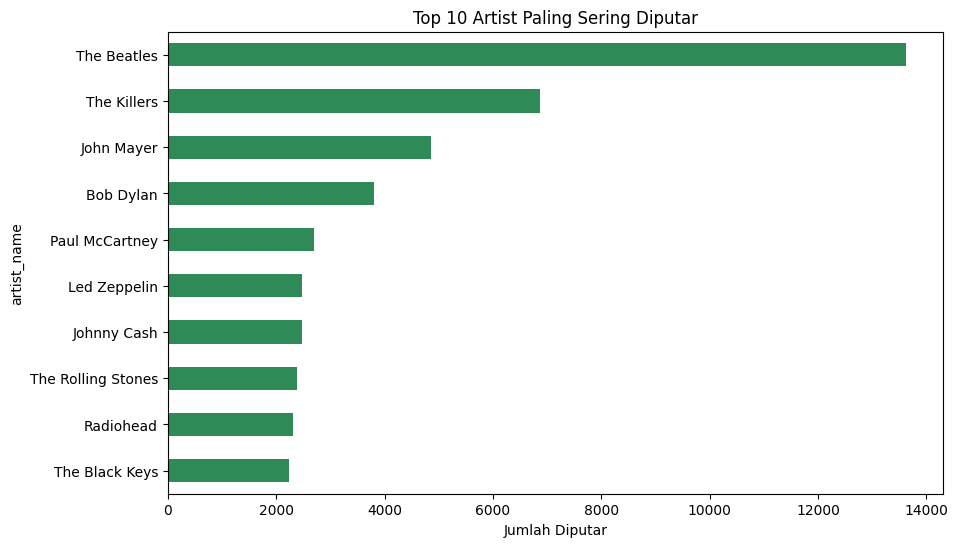

In [11]:
plt.figure(figsize=(10,6))
top_artists.plot(kind='barh', color='seagreen')
plt.title('Top 10 Artist Paling Sering Diputar')
plt.xlabel('Jumlah Diputar')
plt.gca().invert_yaxis()  # biar artist rank 1 di atas
plt.show()

In [12]:
top_artists_by_time = df.groupby('artist_name')['minutes_played'].sum().sort_values(ascending=False).head(10)
top_artists_by_time

artist_name
The Beatles           20166.720767
The Killers           17654.558383
John Mayer            12078.435600
Bob Dylan              9475.533233
Paul McCartney         5955.906167
Howard Shore           5815.511250
The Strokes            5284.948333
The Rolling Stones     5131.950150
Pink Floyd             4342.197367
Led Zeppelin           4123.667667
Name: minutes_played, dtype: float64

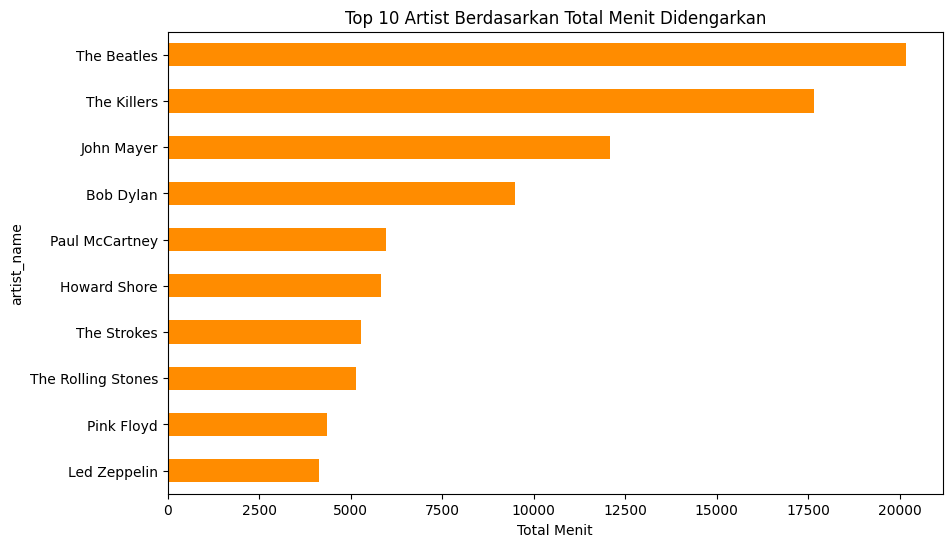

In [13]:
plt.figure(figsize=(10,6))
top_artists_by_time.plot(kind='barh', color='darkorange')
plt.title('Top 10 Artist Berdasarkan Total Menit Didengarkan')
plt.xlabel('Total Menit')
plt.gca().invert_yaxis()
plt.show()

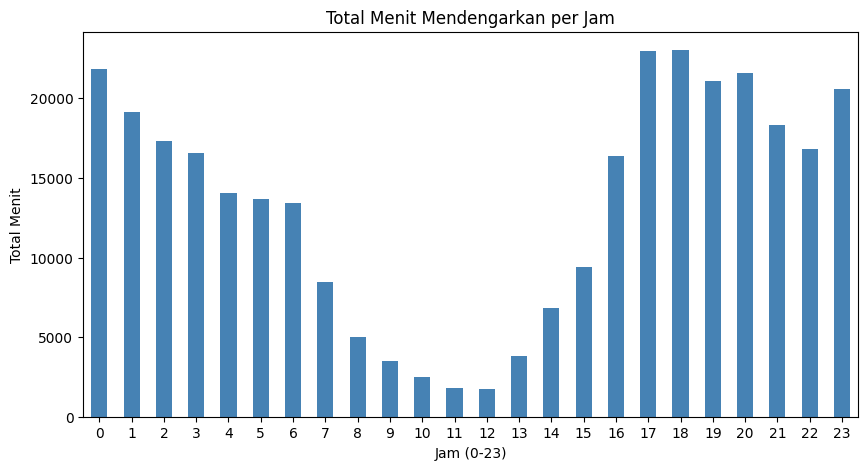

In [14]:
plt.figure(figsize=(10,5))
df.groupby('hour')['minutes_played'].sum().plot(kind='bar', color='steelblue')
plt.title('Total Menit Mendengarkan per Jam')
plt.xlabel('Jam (0-23)')
plt.ylabel('Total Menit')
plt.xticks(rotation=0)
plt.show()

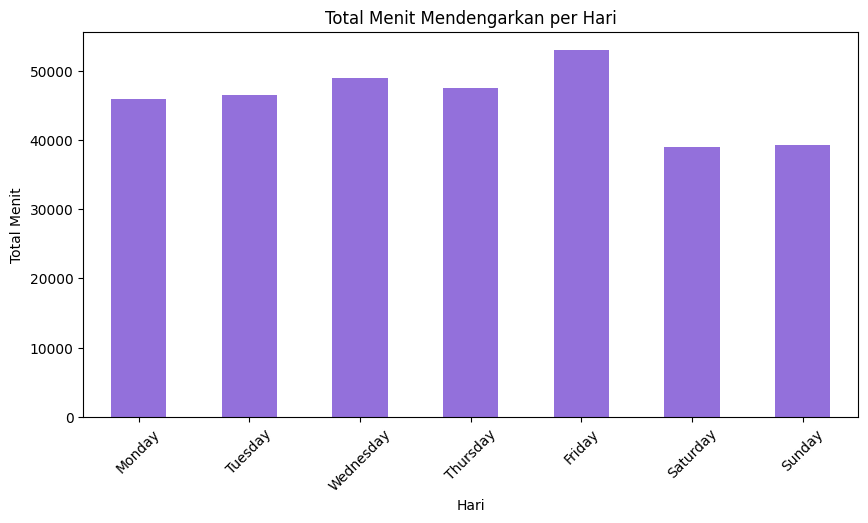

In [15]:
order_hari = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
df.groupby('day_name')['minutes_played'].sum().reindex(order_hari).plot(kind='bar', color='mediumpurple')
plt.title('Total Menit Mendengarkan per Hari')
plt.xlabel('Hari')
plt.ylabel('Total Menit')
plt.xticks(rotation=45)
plt.show()

In [16]:
skip_rate = df['skipped'].value_counts(normalize=True) * 100
skip_rate

skipped
False    94.823853
True      5.176147
Name: proportion, dtype: float64

In [17]:
pd.crosstab(df['shuffle'], df['skipped'], normalize='index') * 100

skipped,False,True
shuffle,,
False,95.887139,4.112861
True,94.460681,5.539319


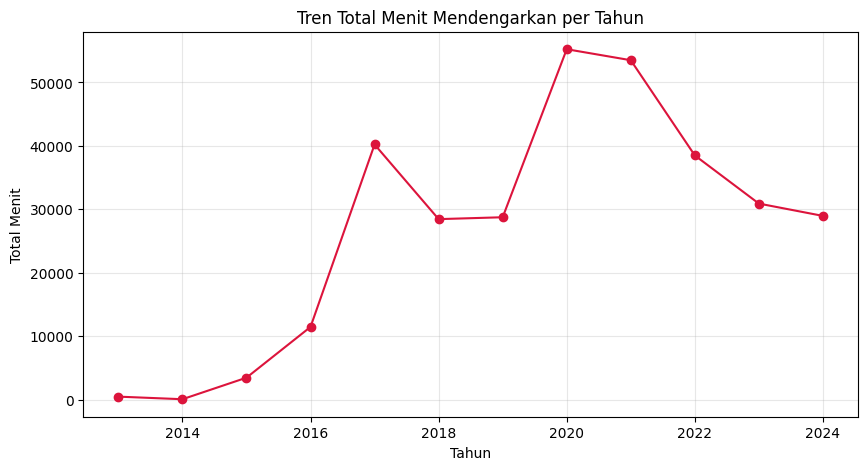

In [18]:
# Tren dari tahun ke tahun
plt.figure(figsize=(10,5))
df.groupby('year')['minutes_played'].sum().plot(kind='line', marker='o', color='crimson')
plt.title('Tren Total Menit Mendengarkan per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Total Menit')
plt.grid(alpha=0.3)
plt.show()